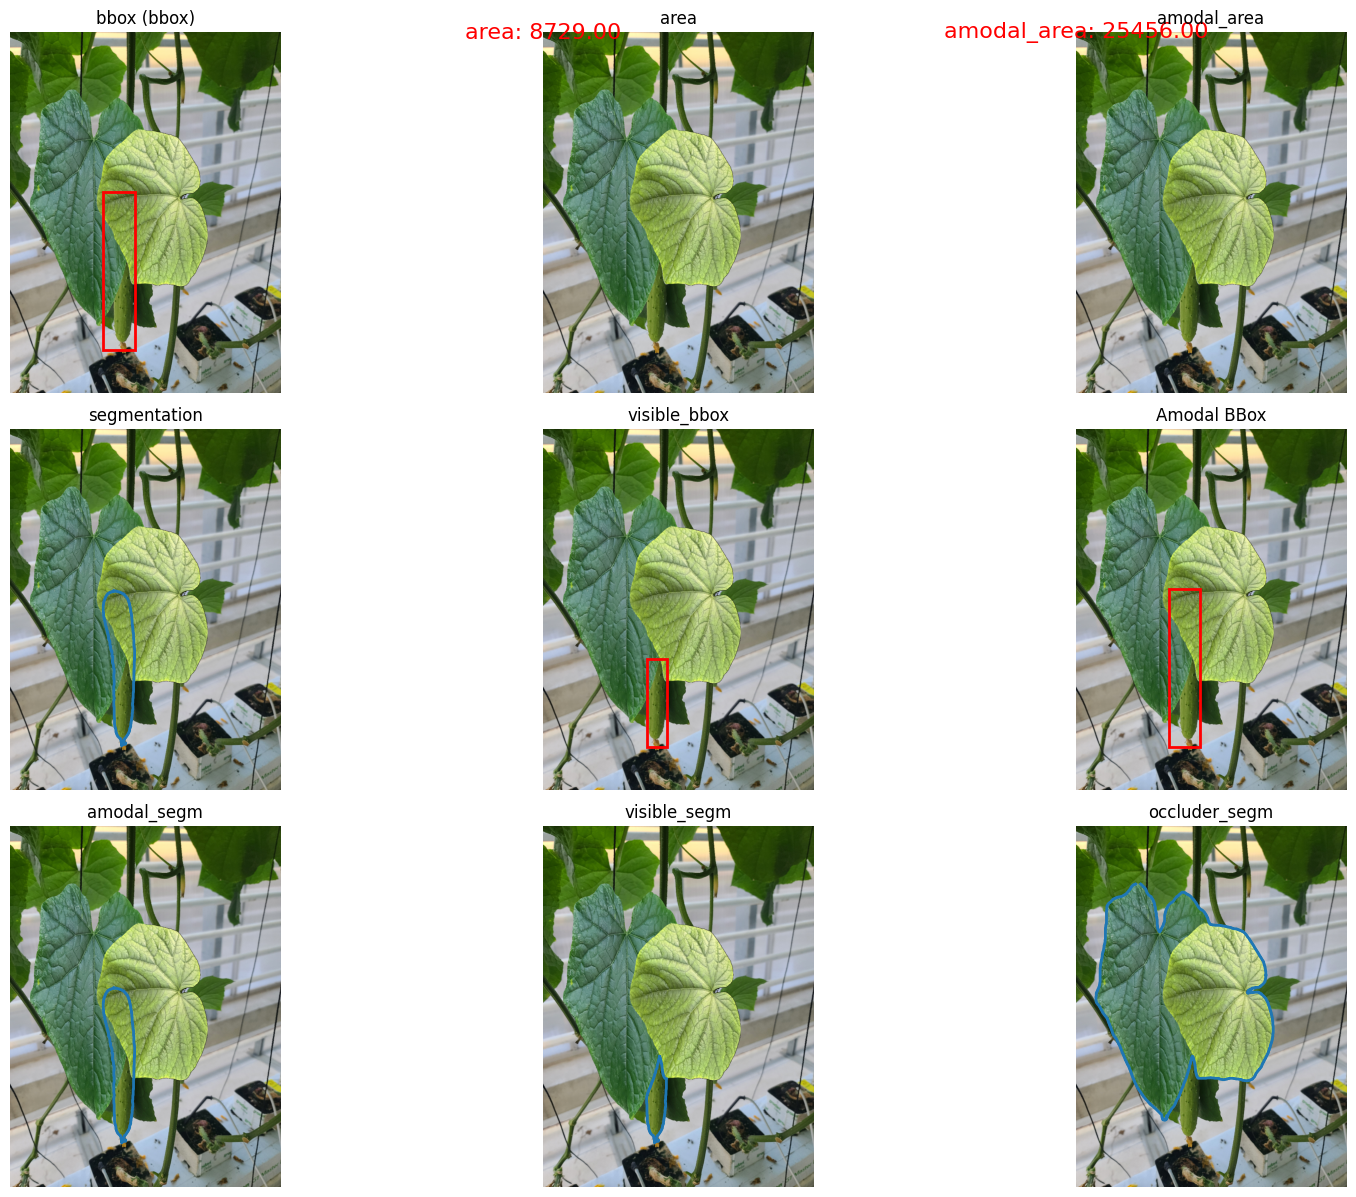

In [1]:
import matplotlib.pyplot as plt
import cv2
import json
import numpy as np

def visualize_single_annotation(annotation, image_path):
    """
    한 개의 annotation의 다양한 요소를 플롯으로 나눠서 시각화.
    
    Args:
        annotation (dict): COCO annotation 정보.
        image_path (str): 이미지 파일 경로.
    """
    # 이미지 로드
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # 플롯 설정
    fig, axs = plt.subplots(3, 3, figsize=(20, 15))
    axs = axs.ravel()

    # 각 요소별 시각화
    elements = {
        "bbox (bbox)": annotation.get("bbox", []),
        "area": annotation.get("area", 0),
        "amodal_area": annotation.get("amodal_area", 0),
        "segmentation": annotation.get("segmentation", []),
        "visible_bbox": annotation.get("visible_bbox", []),
        "Amodal BBox": annotation.get("amodal_bbox", []),
        "amodal_segm": annotation.get("amodal_segm", []),
        "visible_segm": annotation.get("visible_segm", []),
        "occluder_segm": annotation.get("occluder_segm", [])
    }
    
    for i, (key, value) in enumerate(elements.items()):
        ax = axs[i]
        ax.imshow(image)
        ax.set_title(key, fontsize=12)
        
        if key in ["area", "amodal_area"]:
            ax.text(0.5, 0.5, f"{key}: {value:.2f}", fontsize=16, color="red", ha="center", va="center")
            ax.axis("off")
        elif "bbox" in key.lower() and value:
            # COCO bbox는 [x_min, y_min, w, h] 형식
            if len(value) == 4:
                x_min, y_min, width, height = value
                rect = plt.Rectangle((x_min, y_min), width, height, linewidth=2, edgecolor="r", facecolor="none")
                ax.add_patch(rect)
        elif "segmentation" in key and value or "segm" in key and value:
            for polygon in value:
                polygon = np.array(polygon).reshape(-1, 2)
                ax.plot(polygon[:, 0], polygon[:, 1], linewidth=2, label=key)
        ax.axis("off")
    
    # 여백 조정
    plt.subplots_adjust(wspace=0.1, hspace=0.1)  # 여백 줄이기
    plt.show()

# JSON 파일 로드
coco_json_path = "/home/knuvi/Desktop/song/occlusion-mask-generation/data/synthesis/amodal_info_condition3_test2/dataset.json"
image_dir = "/home/knuvi/Desktop/song/occlusion-mask-generation/data/synthesis/amodal_images_condition3_test2"

with open(coco_json_path, "r") as f:
    coco_json = json.load(f)

# 하나의 annotation 선택
selected_annotation = coco_json["annotations"][12]  # 첫 번째 annotation 선택
image_id = selected_annotation["image_id"]

# 이미지 경로 찾기
image_info = next(img for img in coco_json["images"] if img["id"] == image_id)
image_path = f"{image_dir}/{image_info['file_name']}"

# 시각화 호출
visualize_single_annotation(selected_annotation, image_path)


In [3]:
import json

def validate_coco_annotations(json_path):
    with open(json_path, 'r') as f:
        coco_data = json.load(f)
    
    images = coco_data.get("images", [])
    annotations = coco_data.get("annotations", [])
    
    image_ids = set()
    annotation_ids = set()
    errors = []

    cnt_seg_not_1, cnt_vis_not_1 = 0, 0  # 마스크 길이 카운트

    # 이미지 ID 중복 확인
    for image in images:
        if image['id'] in image_ids:
            errors.append(f"중복 이미지 ID: {image['id']}")
        else:
            image_ids.add(image['id'])
    
    # Annotation ID 및 세그멘테이션 구조 검증
    for ann in annotations:
        if ann['id'] in annotation_ids:
            errors.append(f"중복 Annotation ID: {ann['id']}")
        else:
            annotation_ids.add(ann['id'])
        
        # 세그멘테이션 구조 확인
        if "amodal_segm" not in ann or not ann["amodal_segm"]:
            errors.append(f"Annotation {ann['id']}에 amodal_segm이 없습니다.")
        if ann['category_id'] == 1 and "occluder_segm" not in ann:
            errors.append(f"Annotation {ann['id']}에 occluder_segm이 없습니다.")
        
        # segmentation 길이 확인
        if "segmentation" in ann:
            seg_len = len(ann["segmentation"])
            if seg_len != 1:
                cnt_seg_not_1 += 1  # segmentation 길이가 1이 아닌 경우
        
        # visible_segm 길이 확인
        if "visible_segm" in ann:
            vis_len = len(ann["visible_segm"])
            if vis_len != 1:
                cnt_vis_not_1 += 1  # visible_segm 길이가 1이 아닌 경우
    
    # 결과 출력
    if errors:
        print("검증 중 발견된 오류:")
        for error in errors:
            print(error)
    else:
        print("모든 Annotation 및 이미지 ID가 정상입니다.")
    
    # segmentation 및 visible_segm 검증 결과 출력
    print(f"\n검증 요약:")
    print(f"segmentation 길이가 1이 아닌 경우: {cnt_seg_not_1}")
    print(f"visible_segm 길이가 1이 아닌 경우: {cnt_vis_not_1}")

# COCO JSON 파일 검증
validate_coco_annotations("/home/knuvi/Desktop/song/occlusion-mask-generation/data/synthesis/amodal_info_condition3_test2/dataset.json")


모든 Annotation 및 이미지 ID가 정상입니다.

검증 요약:
segmentation 길이가 1이 아닌 경우: 1
visible_segm 길이가 1이 아닌 경우: 4


In [ ]:
import json
from collections import defaultdict

def validate_coco_annotations(json_path):
    with open(json_path, 'r') as f:
        coco_data = json.load(f)
    
    images = coco_data.get("images", [])
    annotations = coco_data.get("annotations", [])
    
    image_ids = set()
    annotation_ids = set()
    errors = []
    cnt_seg_not_1, cnt_vis_not_1 = 0, 0  # 마스크 길이 카운트
    seg_zero, vis_zero = 0, 0  # 마스크 길이 0인 경우 카운트
    # 이미지 ID와 annotation 수 확인용 딕셔너리
    image_annotation_count = defaultdict(int)

    # 이미지 ID 중복 확인
    for image in images:
        if image['id'] in image_ids:
            errors.append(f"중복 이미지 ID: {image['id']}")
        else:
            image_ids.add(image['id'])
    
    # Annotation ID 및 세그멘테이션 구조 검증
    for ann in annotations:
        if ann['id'] in annotation_ids:
            errors.append(f"중복 Annotation ID: {ann['id']}")
        else:
            annotation_ids.add(ann['id'])

        # 이미지에 대한 annotation 수 증가
        image_annotation_count[ann['image_id']] += 1
        
        # 세그멘테이션 구조 확인
        if "amodal_segm" not in ann or not ann["amodal_segm"]:
            errors.append(f"Annotation {ann['id']}에 amodal_segm이 없습니다.")
        if ann['category_id'] == 1 and "occluder_segm" not in ann:
            errors.append(f"Annotation {ann['id']}에 occluder_segm이 없습니다.")
        
        # segmentation 길이 확인
        if "segmentation" in ann:
            seg_len = len(ann["segmentation"])
            if seg_len != 1:
                cnt_seg_not_1 += 1  # segmentation 길이가 1이 아닌 경우
            if seg_len == 0:
                seg_zero += 1
        # visible_segm 길이 확인
        if "visible_segm" in ann:
            vis_len = len(ann["visible_segm"])
            if vis_len != 1:
                cnt_vis_not_1 += 1  # visible_segm 길이가 1이 아닌 경우
            if vis_len == 0:
                vis_zero += 1
    
    # Annotation 개수 검증
    image_with_invalid_annotations = [image_id for image_id, count in image_annotation_count.items() if count != 2]

    # 결과 출력
    if errors:
        print("검증 중 발견된 오류:")
        for error in errors:
            print(error)
    else:
        print("모든 Annotation 및 이미지 ID가 정상입니다.")
    
    # segmentation 및 visible_segm 검증 결과 출력
    print(f"\n검증 요약:")
    print(f"segmentation 길이가 1이 아닌 경우: {cnt_seg_not_1}")
    print(f"visible_segm 길이가 1이 아닌 경우: {cnt_vis_not_1}")
    print(f"segmentation 길이가 0인 경우: {seg_zero}")
    print(f"visible_segm 길이가 0인 경우: {vis_zero}")

    # 이미지별 annotation 개수 확인 결과
    if image_with_invalid_annotations:
        print("\nAnnotation 개수가 2개가 아닌 이미지:")
        for image_id in image_with_invalid_annotations:
            print(f"이미지 ID: {image_id}, Annotation 개수: {image_annotation_count[image_id]}")
    else:
        print("\n모든 이미지에 대해 Annotation 개수가 2개입니다.")

# COCO JSON 파일 검증
validate_coco_annotations("/home/knuvi/Desktop/song/occlusion-mask-generation/data/synthesis/amodal_info_condition2_test2/dataset.json")


모든 Annotation 및 이미지 ID가 정상입니다.

검증 요약:
segmentation 길이가 1이 아닌 경우: 1
visible_segm 길이가 1이 아닌 경우: 4
segmentation 길이가 0인 경우: 0
visible_segm 길이가 0인 경우: 0

모든 이미지에 대해 Annotation 개수가 2개입니다.


In [ ]:
import matplotlib.pyplot as plt
import cv2
import json
import numpy as np
import os

def visualize_annotations_by_image(image_file_name, coco_json_path, image_dir):
    """
    특정 이미지 파일에 대한 모든 어노테이션 시각화.
    
    Args:
        image_file_name (str): 처리할 이미지 파일 이름 (예: "000000.png").
        coco_json_path (str): COCO JSON 파일 경로.
        image_dir (str): 이미지 파일이 저장된 디렉토리.
    """
    # JSON 파일 로드
    with open(coco_json_path, "r") as f:
        coco_json = json.load(f)
    
    # 해당 이미지 정보 찾기
    image_info = next((img for img in coco_json["images"] if img["file_name"] == image_file_name), None)
    if image_info is None:
        print(f"이미지 파일 {image_file_name}에 대한 정보가 없습니다.")
        return
    
    # 이미지 파일 경로 생성
    image_path = os.path.join(image_dir, image_file_name)
    if not os.path.exists(image_path):
        print(f"이미지 파일이 존재하지 않습니다: {image_path}")
        return
    
    # 해당 이미지의 모든 어노테이션 찾기
    annotations = [ann for ann in coco_json["annotations"] if ann["image_id"] == image_info["id"]]
    if not annotations:
        print(f"이미지 {image_file_name}에 대한 어노테이션이 없습니다.")
        return
    
    # 이미지 로드
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # 어노테이션 시각화
    for i, annotation in enumerate(annotations):
        print(f"시각화 중: 어노테이션 ID {annotation['id']}")
        fig, axs = plt.subplots(3, 3, figsize=(20, 15))
        axs = axs.ravel()
        
        elements = {
            "bbox (bbox)": annotation.get("bbox", []),
            "area": annotation.get("area", 0),
            "amodal_area": annotation.get("amodal_area", 0),
            "segmentation": annotation.get("segmentation", []),
            "visible_bbox": annotation.get("visible_bbox", []),
            "Amodal BBox": annotation.get("amodal_bbox", []),
            "amodal_segm": annotation.get("amodal_segm", []),
            "visible_segm": annotation.get("visible_segm", []),
            "occluder_segm": annotation.get("occluder_segm", [])
        }
        
        for j, (key, value) in enumerate(elements.items()):
            ax = axs[j]
            ax.imshow(image)
            ax.set_title(key, fontsize=12)
            
            if key in ["area", "amodal_area"]:
                ax.text(0.5, 0.5, f"{key}: {value:.2f}", fontsize=16, color="red", ha="center", va="center")
                ax.axis("off")
            elif "bbox" in key.lower() and value:
                # COCO bbox는 [x_min, y_min, w, h] 형식
                if len(value) == 4:
                    x_min, y_min, width, height = value
                    rect = plt.Rectangle((x_min, y_min), width, height, linewidth=2, edgecolor="r", facecolor="none")
                    ax.add_patch(rect)
            elif "segmentation" in key and value or "segm" in key and value:
                for polygon in value:
                    polygon = np.array(polygon).reshape(-1, 2)
                    ax.plot(polygon[:, 0], polygon[:, 1], linewidth=2, label=key)
            ax.axis("off")
        
        plt.subplots_adjust(wspace=0.1, hspace=0.1)  # 여백 줄이기
        plt.show()

# 경로 설정
coco_json_path = "/home/knuvi/Desktop/song/occlusion-mask-generation/jsonformat/train.json"
image_dir = "/home/knuvi/Desktop/song/occlusion-mask-generation/jsonformat"
image_file_name = "000000.png"  # 처리할 이미지 파일 이름

# 호출
visualize_annotations_by_image(image_file_name, coco_json_path, image_dir)


FileNotFoundError: [Errno 2] No such file or directory: '/home/knuvi/Desktop/song/occlusion-mask-generation/jsonformat/train.json'

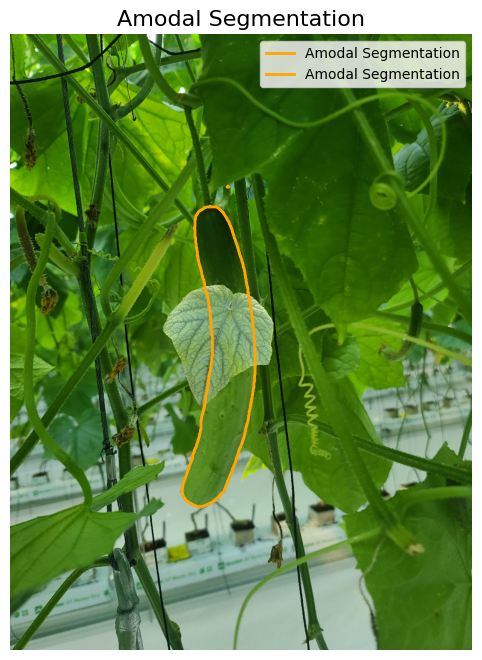

In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

def visualize_amodal_segm(annotation, image_path):
    # 이미지 로드
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Amodal Segmentation 데이터 가져오기
    amodal_segm = annotation.get("amodal_segm", [])

    if not amodal_segm:
        print("Amodal Segmentation 데이터가 없습니다.")
        return

    # 이미지 시각화
    plt.figure(figsize=(10, 8))
    plt.imshow(image)
    plt.title("Amodal Segmentation", fontsize=16)

    # Amodal Segmentation 시각화
    for polygon in amodal_segm:
        polygon = np.array(polygon).reshape(-1, 2)  # 1차원 리스트를 2차원 배열로 변환
        plt.plot(polygon[:, 0], polygon[:, 1], linewidth=2, label="Amodal Segmentation", color="orange")

    plt.axis("off")
    plt.legend()
    plt.show()

# JSON 파일 로드
import json

coco_json_path = "/home/knuvi/Desktop/song/occlusion-mask-generation/data/synthesis/amodal_info1/dataset.json"
image_dir = "/home/knuvi/Desktop/song/occlusion-mask-generation/data/synthesis/amodal_images1"

with open(coco_json_path, "r") as f:
    coco_json = json.load(f)

# 하나의 annotation 선택
selected_annotation = coco_json["annotations"][0]  # 두 번째 annotation 선택
image_id = selected_annotation["image_id"]

# 이미지 경로 찾기
image_info = next(img for img in coco_json["images"] if img["id"] == image_id)
image_path = f"{image_dir}/{image_info['file_name']}"

# 시각화 호출
visualize_amodal_segm(selected_annotation, image_path)
